
# Analyse Exploratoire des Incidents Logiciels

## 1. Introduction

Ce projet vise à analyser un dataset d’incidents logiciels classifiés selon leur niveau de sévérité, leur domaine fonctionnel et la technologie concernée.

Objectifs principaux :
- Identifier les technologies les plus exposées
- Déterminer les domaines les plus critiques
- Analyser les combinaisons à risque entre sévérité et stack technique
- Mettre en évidence les codes d’erreur récurrents

Cette analyse exploratoire (EDA) permettra d’orienter des décisions d’amélioration technique.



## 2. Description du Dataset

Variables principales :

- **severity** : niveau de gravité (Low, Medium, High, Critical)
- **tech_stack** : technologie concernée
- **bug_category** : type de problème
- **bug_domain** : domaine fonctionnel
- **error_code** : code spécifique d’erreur

Les données couvrent plusieurs périodes, permettant une analyse comparative.



## 3. Nettoyage et Préparation des Données

### Traitement des valeurs manquantes

Les valeurs NULL dans `error_code` ont été imputées par le **mode conditionnel**.

Pour chaque combinaison :
(severity, bug_category, tech_stack)

Les valeurs manquantes ont été remplacées par le code d’erreur le plus fréquent du groupe.

Objectif :
- Préserver la cohérence contextuelle
- Éviter l’introduction d’une nouvelle catégorie artificielle
- Réduire le biais statistique


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('bug_dataset_50k.csv')

In [17]:
df.columns

Index(['bug_id', 'title', 'description', 'error_code', 'bug_category',
       'bug_domain', 'tech_stack', 'severity', 'environment', 'developer_role',
       'root_cause', 'suggested_fix', 'explanation', 'created_at'],
      dtype='str')

In [18]:
df['created_at'] = pd.to_datetime(df['created_at'], errors = 'coerce')
df['mois'] = df['created_at'].dt.to_period('M')
df['error_code'] = (
    df.groupby(['severity', 'bug_category', 'tech_stack'])['error_code']
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x))
)

In [19]:
df['mois'].unique()

<PeriodArray>
['2025-04', '2025-07', '2025-05', '2025-09', '2025-08', '2025-06', '2026-01',
 '2025-12', '2025-10', '2025-03', '2025-11', '2025-02', '2026-02']
Length: 13, dtype: period[M]

In [20]:
# je crois qu'il soit plus interessant qu'on crée une variable pour chaque 3 mois
fv_ap_25 = df[df['mois'].astype(str).isin(['2025-02','2025-03','2025-04'])]
ma_jl_25 = df[df['mois'].astype(str).isin(['2025-05','2025-06','2025-07'])]
ag_ou_25 = df[df['mois'].astype(str).isin(['2025-08','2025-09','2025-10'])]
nv_jn_26 = df[df['mois'].astype(str).isin(['2025-11','2025-12','2026-01'])]

back_sys = df[df['bug_domain'] == 'Backend Systems']
mobile = df[df['bug_domain'] == 'Mobile']
data = df[df['bug_domain'] == 'Data']
web_dev = df[df['bug_domain'] == 'Web Development']
dev_ops = df[df['bug_domain'] == 'DevOps']
cloud = df[df['bug_domain'] == 'Cloud']



In [21]:
df['bug_domain'].unique()

<StringArray>
['Mobile', 'Data', 'DevOps', 'Backend Systems', 'Web Development', 'Cloud']
Length: 6, dtype: str

In [22]:
df['bug_category'].unique()

<StringArray>
[                'API Bug',             'Memory Leak',
 'Cloud Configuration Bug',      'Authentication Bug',
             'Logging Bug',    'Frontend Routing Bug',
               'CI/CD Bug',                  'UI Bug',
         'Concurrency Bug',          'Monitoring Bug',
         'Performance Bug',       'Authorization Bug',
          'Deployment Bug',       'Backend Logic Bug',
            'Database Bug',  'Security Vulnerability']
Length: 16, dtype: str

In [23]:
data = [fv_ap_25,ma_jl_25,ag_ou_25,nv_jn_26] # 'DATA' DEVIENT NOTRE PRINCIPAL VARIABLE

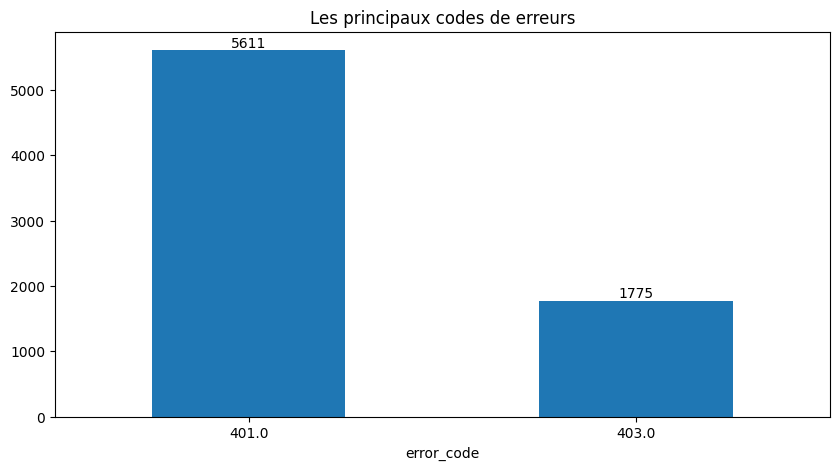

In [24]:
########ERROR_CODE###############
# Ici nous regroupons par le principal code d'erreur de chaque période
results_bug = []
for i in data :
    dt = i.groupby('error_code').size().sort_values(ascending = False).head(1)
    dt.dropna()
    results_bug.append(dt)
dt_errcd = pd.concat(results_bug)   
dt_errcd = dt_errcd.sort_values(ascending = False)
dt_errcd #ici nous avons les principaux bugs de chaque période

#Dans notre analyse, nous avons deux codes d’erreur principaux observés sur quatre périodes distinctes.
#Comme error_code est utilisé comme index, nous pouvons regrouper les lignes ayant le même index afin d’agréger les valeurs associées.
#L’utilisation de groupby(dt_errcd.index).sum() permet donc de calculer le total des occurrences pour chaque code d’erreur sur l’ensemble des périodes.
bug_c = (
    dt_errcd
    .groupby(dt_errcd.index)
    .sum()
)
bug_c
plt.figure(figsize = (10,5))
ax = bug_c.plot(kind = 'bar')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Les principaux codes de erreurs')
plt.xticks(rotation = 0)
plt.show()


### Interprétation

Ce graphique permet d’identifier les concentrations d’incidents selon les dimensions étudiées.

Les zones les plus intenses indiquent des combinaisons critiques nécessitant une attention prioritaire.

Ces résultats peuvent s’expliquer par :
- Une complexité technique plus élevée
- Une forte dépendance à certaines technologies
- Un volume d’utilisation plus important


<Figure size 1000x500 with 0 Axes>

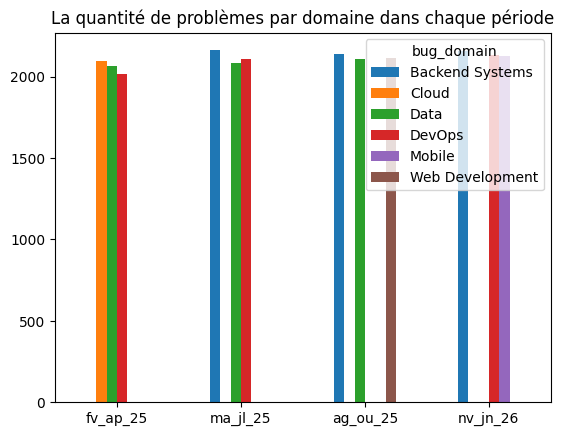

In [25]:
a = fv_ap_25.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
b = ma_jl_25.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
c = ag_ou_25.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
d = nv_jn_26.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
dt_bug_dm = pd.DataFrame({
    'fv_ap_25': a,
    'ma_jl_25': b,
    'ag_ou_25': c,
    'nv_jn_26': d
})
dt_bug_dm
dt_bug_dm = dt_bug_dm.T
dt_bug_dm = dt_bug_dm.fillna(0)
dt_bug_dm
plt.figure(figsize = (10,5))
dt_bug_dm.plot(kind = 'bar')
plt.title('La quantité de problèmes par domaine dans chaque période')
plt.xticks(rotation = 0)
plt.show()


### Interprétation

Ce graphique permet d’identifier les concentrations d’incidents selon les dimensions étudiées.

Les zones les plus intenses indiquent des combinaisons critiques nécessitant une attention prioritaire.

Ces résultats peuvent s’expliquer par :
- Une complexité technique plus élevée
- Une forte dépendance à certaines technologies
- Un volume d’utilisation plus important


In [26]:
df

,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,environment,developer_role,root_cause,suggested_fix,explanation,created_at,mois
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in t...,403.0,API Bug,Mobile,Spring Boot,High,Development,Full-Stack Developer,Misconfiguration or logic issue related to api...,Review and fix the api bug according to best p...,This bug requires a full-stack developer due t...,2025-04-07,2025-04
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Data,GCP,Medium,Production,Backend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a backend developer due to i...,2025-07-04,2025-07
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bu...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to clo...,Review and fix the cloud configuration bug acc...,This bug requires a mobile developer due to it...,2025-05-02,2025-05
3,BUG_000004,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Backend Systems,Flask,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a mobile developer due to it...,2025-07-03,2025-07
4,BUG_000005,Logging Bug detected in system,This issue relates to a logging bug occurring ...,503.0,Logging Bug,Mobile,Flask,High,Staging,Backend Developer,Misconfiguration or logic issue related to log...,Review and fix the logging bug according to be...,This bug requires a backend developer due to i...,2025-09-09,2025-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,BUG_049996,CI/CD Bug detected in system,This issue relates to a ci/cd bug occurring in...,500.0,CI/CD Bug,DevOps,Vue,Critical,Staging,Security Engineer,Misconfiguration or logic issue related to ci/...,Review and fix the ci/cd bug according to best...,This bug requires a security engineer due to i...,2025-11-17,2025-11
49996,BUG_049997,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Web Development,MySQL,High,Production,Frontend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a frontend developer due to ...,2025-11-18,2025-11
49997,BUG_049998,Database Bug detected in system,This issue relates to a database bug occurring...,403.0,Database Bug,Data,AWS,Low,Production,Data Engineer,Misconfiguration or logic issue related to dat...,Review and fix the database bug according to b...,This bug requires a data engineer due to its n...,2025-09-26,2025-09
49998,BUG_049999,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Cloud,AWS,High,Development,Security Engineer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a security engineer due to i...,2025-05-03,2025-05


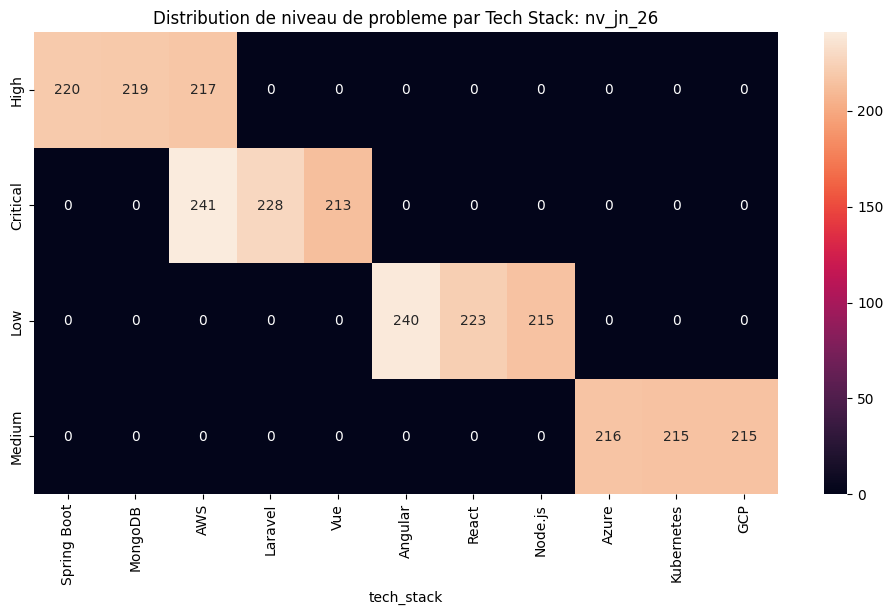

In [35]:
#L’analyse révèle qu’AWS est la seule technologie affichant simultanément des incidents de sévérité High et Critical,
#avec un total cumulé de 458 incidents, ce qui en fait la stack la plus exposée aux problèmes critiques.
data = nv_jn_26
col_1 = 'severity'
col_2 = 'tech_stack'

tec_nv_jn_26 = (
    data
    .groupby([col_1,col_2])
    .size()
    .sort_values(ascending = False)
)
index = data['severity'].unique()
r = []
for i in index:
    g = tec_nv_jn_26[i].head(3)
    r.append(g)
dt_anl = pd.DataFrame(r)
dt_anl.index = index.tolist()
dt_anl_ = dt_anl.fillna(0)
plt.figure(figsize=(12,6))
sns.heatmap(dt_anl_, annot=True, fmt=".0f")
plt.title("Distribution de niveau de probleme par Tech Stack: nv_jn_26")
plt.show()
##############################################3


### Interprétation

Ce graphique permet d’identifier les concentrations d’incidents selon les dimensions étudiées.

Les zones les plus intenses indiquent des combinaisons critiques nécessitant une attention prioritaire.

Ces résultats peuvent s’expliquer par :
- Une complexité technique plus élevée
- Une forte dépendance à certaines technologies
- Un volume d’utilisation plus important


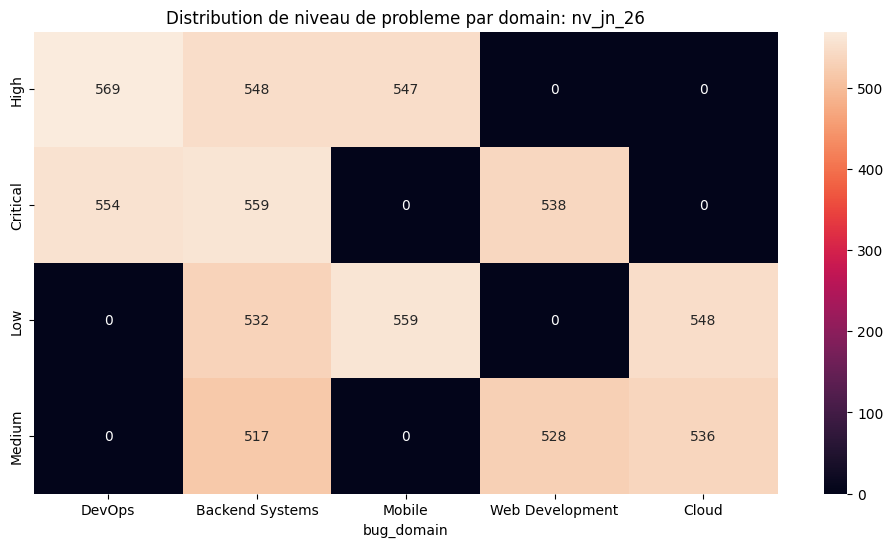

In [44]:
data = nv_jn_26
col_1 = 'severity'
col_2 = 'bug_domain'

tec_nv_jn_26 = (
    data
    .groupby([col_1,col_2])
    .size()
    .sort_values(ascending = False)
)
index = data['severity'].unique()
r = []
for i in index:
    g = tec_nv_jn_26[i].head(3)
    r.append(g)
dt_anl = pd.DataFrame(r)
dt_anl.index = index.tolist()
dt_anl_ = dt_anl.fillna(0)
plt.figure(figsize=(12,6))
sns.heatmap(dt_anl_, annot=True, fmt=".0f")
plt.title("Distribution de niveau de probleme par domain: nv_jn_26")
plt.show()


### Interprétation

Ce graphique permet d’identifier les concentrations d’incidents selon les dimensions étudiées.

Les zones les plus intenses indiquent des combinaisons critiques nécessitant une attention prioritaire.

Ces résultats peuvent s’expliquer par :
- Une complexité technique plus élevée
- Une forte dépendance à certaines technologies
- Un volume d’utilisation plus important


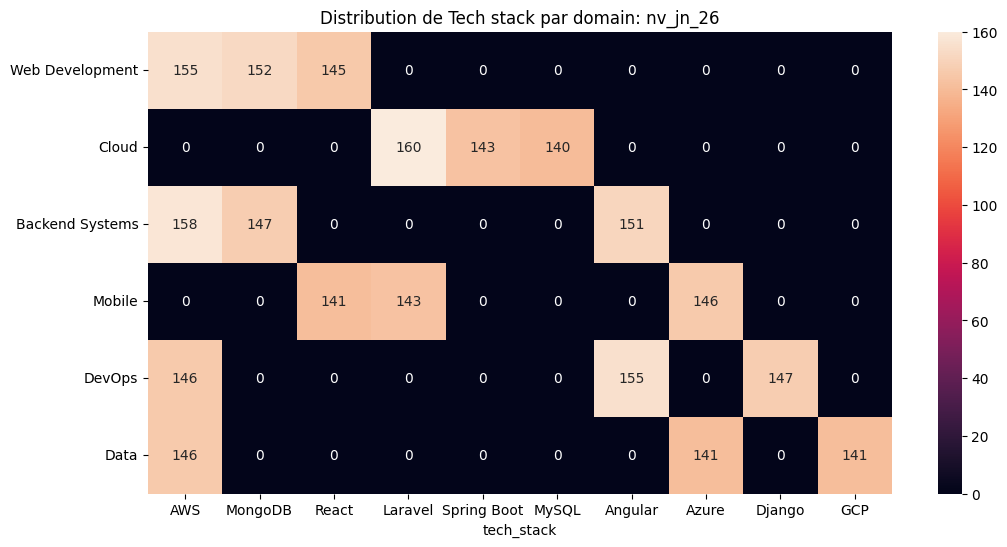

In [45]:
data = nv_jn_26
col_1 = 'bug_domain'
col_2 = 'tech_stack'

tec_nv_jn_26 = (
    data
    .groupby([col_1,col_2])
    .size()
    .sort_values(ascending = False)
)
index = data['bug_domain'].unique()
r = []
for i in index:
    g = tec_nv_jn_26[i].head(3)
    r.append(g)
dt_anl = pd.DataFrame(r)
dt_anl.index = index.tolist()
dt_anl_ = dt_anl.fillna(0)
plt.figure(figsize=(12,6))
sns.heatmap(dt_anl_, annot=True, fmt=".0f")
plt.title("Distribution de Tech stack par domain: nv_jn_26")
plt.show()
######################################3



### Interprétation

Ce graphique permet d’identifier les concentrations d’incidents selon les dimensions étudiées.

Les zones les plus intenses indiquent des combinaisons critiques nécessitant une attention prioritaire.

Ces résultats peuvent s’expliquer par :
- Une complexité technique plus élevée
- Une forte dépendance à certaines technologies
- Un volume d’utilisation plus important


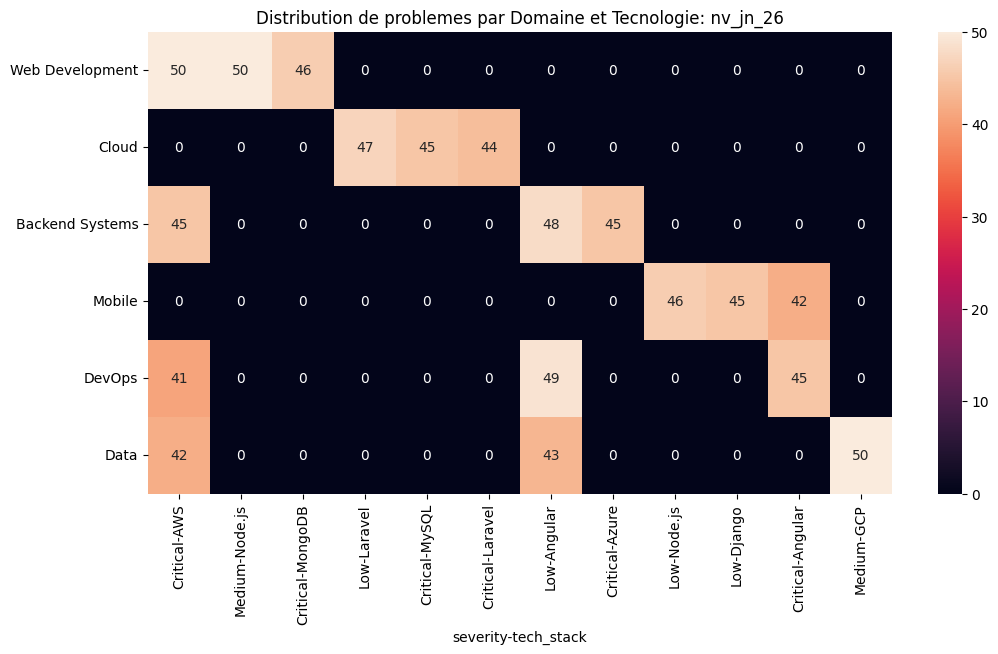

In [46]:
data = nv_jn_26
col_1 = 'bug_domain'
col_2 = 'severity'
col_3 = 'tech_stack'
tec_nv_jn_26 = (
    data
    .groupby([col_1,col_2,col_3])
    .size()
    .sort_values(ascending = False)
)
index = data['bug_domain'].unique()
r = []
for i in index:
    g = tec_nv_jn_26[i].head(3)
    r.append(g)
dt_anl = pd.DataFrame(r)
dt_anl.index = index.tolist()
dt_anl_ = dt_anl.fillna(0)
plt.figure(figsize=(12,6))
sns.heatmap(dt_anl_, annot=True, fmt=".0f")
plt.title("Distribution de problemes par Domaine et Tecnologie: nv_jn_26")
plt.show()


### Interprétation

Ce graphique permet d’identifier les concentrations d’incidents selon les dimensions étudiées.

Les zones les plus intenses indiquent des combinaisons critiques nécessitant une attention prioritaire.

Ces résultats peuvent s’expliquer par :
- Une complexité technique plus élevée
- Une forte dépendance à certaines technologies
- Un volume d’utilisation plus important


In [47]:
tec_nv_jn_26

bug_domain       severity  tech_stack
Web Development  Critical  AWS           50
                 Medium    Node.js       50
Data             Medium    GCP           50
DevOps           Low       Angular       49
Backend Systems  Low       Angular       48
                                         ..
DevOps           Medium    PostgreSQL    20
Mobile           Low       Kubernetes    20
DevOps           Low       Vue           17
Data             Medium    Django        17
                           React         15
Length: 384, dtype: int64

In [49]:
aws = nv_jn_26[nv_jn_26['tech_stack'] == 'AWS']

In [50]:
svtc = (
    nv_jn_26
    .groupby(['tech_stack','severity'])
    .size()
    .sort_values(ascending = False)
)

tc = nv_jn_26['tech_stack'].unique()
var_svtc = []
for i in tc:
    sv_ = svtc[i]
    var_svtc.append(sv_)
df_svtc = pd.DataFrame(var_svtc)

df_svtc.index = tc.tolist()

df_svtc

severity,Critical,High,Low,Medium
PostgreSQL,197,195,192,191
Kubernetes,179,197,161,215
MySQL,197,210,170,201
Docker,170,186,179,209
Angular,202,202,240,196
MongoDB,206,219,196,201
Spring Boot,186,220,180,188
Azure,209,208,189,216
AWS,241,217,208,197
Vue,213,178,188,169


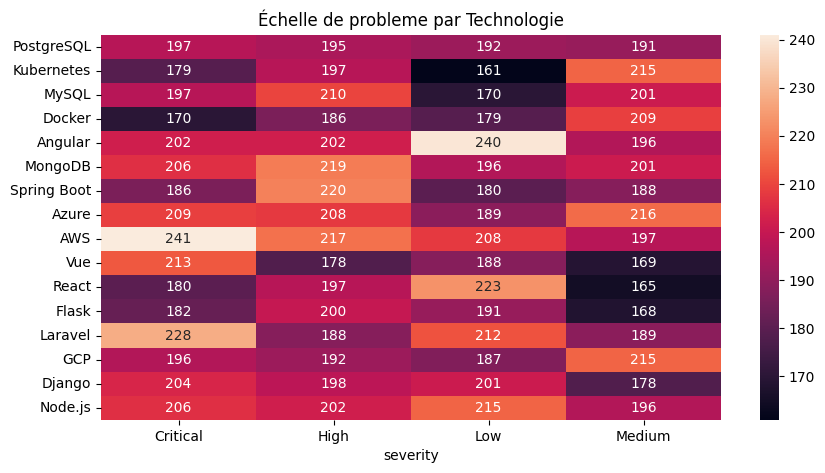

In [51]:
plt.figure(figsize = (10,5))
sns.heatmap(df_svtc, annot=True, fmt=".0f")
plt.title('Échelle de probleme par Technologie')
plt.show()


### Interprétation

Ce graphique permet d’identifier les concentrations d’incidents selon les dimensions étudiées.

Les zones les plus intenses indiquent des combinaisons critiques nécessitant une attention prioritaire.

Ces résultats peuvent s’expliquer par :
- Une complexité technique plus élevée
- Une forte dépendance à certaines technologies
- Un volume d’utilisation plus important



## 8. Insights Clés

- Certaines technologies concentrent la majorité des incidents critiques.
- Le domaine Backend apparaît structurellement plus exposé.
- Certains codes d’erreur sont récurrents sur plusieurs périodes.
- La sévérité élevée semble associée à des environnements techniques complexes.

Ces constats permettent d’orienter les priorités d’amélioration.



## 9. Conclusion Générale

L’analyse exploratoire met en évidence des tendances structurantes dans la distribution des incidents.

Les résultats suggèrent une concentration significative des incidents critiques dans certains domaines et sur certaines technologies spécifiques.

Ce travail constitue une base solide pour :

- Prioriser les efforts de correction
- Optimiser la gestion des incidents
- Développer un futur modèle prédictif de sévérité

Ainsi, cette étude dépasse la simple description statistique et propose des pistes d’amélioration stratégique et technique.
